# Analyse av manual review-tags i mappings-JSON-filer

Les alle JSON-filer fra `mappings*`-mapper og lag plots for review-analyse.

**Sett `ROOT` til mappen der `mappings`-undermappene dine ligger.**

In [6]:
from pathlib import Path

# ── KONFIGURASJON — endre disse ────────────────────────────────────
ROOT    = Path("../data/mappings/prof_mappings")
OUT_DIR = Path("plot_exports")
TOP_N   = 20

INCLUDE_FOLDERS = {"mappings_cox", "mappings_hex", "mappings_isx", 
                   "mappings_obx", "mappings_stx"}
# ────────────────────────────────────────────────────────────────────

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Root: {ROOT.resolve()}")
print(f"Output: {OUT_DIR.resolve()}")

Root: /Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/data/mappings/prof_mappings
Output: /Users/fredrikfuglerudflugstad/Library/Mobile Documents/com~apple~CloudDocs/Skole/NTNU/Industriell Økonomi og Teknologiledelse/10. Semester/Equity_Quality_Under_Uncertainty/manual_review/plot_exports


## Importer og plot-tema

In [7]:
import json
import re
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

THEME = {
    "figure.facecolor": "#f5f5f7",
    "axes.facecolor": "#ebedf2",
    "axes.edgecolor": "#c9ced8",
    "axes.labelcolor": "#2f3b4a",
    "axes.titlecolor": "#1f2937",
    "axes.grid": True,
    "grid.color": "#b8c0cc",
    "grid.linestyle": "--",
    "grid.alpha": 0.45,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 17,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.color": "#435165",
    "ytick.color": "#435165",
    "legend.frameon": False,
    "figure.autolayout": False,
}

PALETTE = {
    "blue":   "#4C78A8",
    "teal":   "#54A6A6",
    "green":  "#72B7B2",
    "orange": "#F2A65A",
    "red":    "#D95F5F",
    "gold":   "#E9C46A",
    "navy":   "#2A4E6E",
    "slate":  "#7B8BA3",
}

TAG_COLORS = {
    "CR:c":  PALETTE["red"],
    "CR:nc": PALETTE["orange"],
    "R:c":   PALETTE["blue"],
    "R:nc":  PALETTE["teal"],
    "none":  PALETTE["slate"],
}

plt.rcParams.update(THEME)
if HAS_SEABORN:
    sns.set_theme(style="darkgrid", rc=THEME)

print("Tema lastet.")

Tema lastet.


## Hjelpefunksjoner

In [8]:
def fmt_int(x, pos=None):
    try:
        return f"{int(x):,}"
    except Exception:
        return str(x)

def style_axis(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title, pad=12)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_int))

def add_bar_labels(ax, fmt="{:,.0f}", pad_frac=0.01):
    heights = [p.get_height() for p in ax.patches]
    ymax = max(heights, default=0)
    offset = ymax * pad_frac if ymax > 0 else 0.1
    for patch in ax.patches:
        v = patch.get_height()
        if v > 0:
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                v + offset,
                fmt.format(v),
                ha="center", va="bottom",
                fontsize=10, color="#253243", fontweight="semibold",
            )

def extract_tag(notes: str) -> str:
    if not notes:
        return "none"
    m = re.search(r'\b(CR:nc|CR:c|R:nc|R:c)\b', notes, re.IGNORECASE)
    if m:
        return m.group(1).upper().replace("NC", "nc").replace(":C", ":c")
    return "none"

def extract_cr_severity(notes: str):
    if not notes:
        return None
    m = re.search(r'CR:c\|(\w+)', notes, re.IGNORECASE)
    return m.group(1).lower() if m else None

def extract_cr_reason(notes: str):
    if not notes:
        return None
    m = re.search(r'CR:c\|\w+\|(\w+)', notes, re.IGNORECASE)
    return m.group(1).lower() if m else None

print("Hjelpefunksjoner definert.")

Hjelpefunksjoner definert.


## Last inn data fra mappings-mapper

In [11]:
def load_all_mappings(root: Path) -> pd.DataFrame:
    records = []
    mapping_dirs = [d for d in root.iterdir() 
                if d.is_dir() and d.name in INCLUDE_FOLDERS]
    if not mapping_dirs:
        for subdir in root.iterdir():
            if subdir.is_dir():
                mapping_dirs = [d for d in root.iterdir() if d.is_dir() and d.name.endswith("mappings")]
    if not mapping_dirs:
        raise FileNotFoundError(f"Fant ingen mappings*-mapper under {root}.")

    print(f"Fant {len(mapping_dirs)} mappings-mapper:")
    for folder in sorted(mapping_dirs):
        json_files = list(folder.rglob("*.json"))
        print(f"  {folder.name}: {len(json_files)} JSON-filer")
        for jf in json_files:
            try:
                data = json.loads(jf.read_text(encoding="utf-8"))
            except Exception as e:
                print(f"    ADVARSEL: {jf.name}: {e}")
                continue
            company = jf.stem
            for var_obj in data.get("variables", []):
                variable = var_obj.get("variable", "UNKNOWN")
                notes    = var_obj.get("notes", "") or ""
                needs_mr = bool(var_obj.get("needs_manual_review", False))
                candidates = var_obj.get("candidates", [])
                max_confidence = max((c.get("confidence", 0) for c in candidates), default=None)
                tag      = extract_tag(notes)
                severity = extract_cr_severity(notes)
                reason   = extract_cr_reason(notes)
                records.append({
                    "folder": folder.name, "company": company, "variable": variable,
                    "notes": notes, "tag": tag, "needs_mr": needs_mr,
                    "n_candidates": len(candidates), "n_final": len(var_obj.get("final_choice", [])),
                    "max_confidence": max_confidence, "cr_severity": severity, "cr_reason": reason,
                    "has_review": tag != "none",
                    "is_confirmed": tag in ("CR:c", "R:c"),
                    "is_cost_ratio": tag.startswith("CR"),
                })
    df = pd.DataFrame(records)
    print(f"\nTotalt {len(df)} variabel-oppføringer fra {df['company'].nunique()} selskaper.")
    return df

df = load_all_mappings(ROOT)

Fant 5 mappings-mapper:
  mappings_cox: 87 JSON-filer
  mappings_hex: 119 JSON-filer
  mappings_isx: 22 JSON-filer
  mappings_obx: 148 JSON-filer
  mappings_stx: 262 JSON-filer

Totalt 4466 variabel-oppføringer fra 638 selskaper.


## Sammendrag

In [12]:
print('\n' + '═'*55)
print('  SAMMENDRAG')
print('═'*55)
print(f"  Totale variabel-oppføringer : {len(df):,}")
print(f"  Unike selskaper             : {df['company'].nunique():,}")
print(f"  Unike mapper                : {df['folder'].nunique():,}")
print()
tag_counts = df['tag'].value_counts()
for tag in ['CR:c', 'CR:nc', 'R:c', 'R:nc', 'none']:
    n = tag_counts.get(tag, 0)
    pct = n / len(df) * 100
    print(f"  {tag:<8} : {n:>5,}  ({pct:5.1f}%)")
print()
print(f"  needs_manual_review=True    : {df['needs_mr'].sum():,}")
print('═'*55)


═══════════════════════════════════════════════════════
  SAMMENDRAG
═══════════════════════════════════════════════════════
  Totale variabel-oppføringer : 4,466
  Unike selskaper             : 638
  Unike mapper                : 5

  CR:c     :   344  (  7.7%)
  CR:nc    :    81  (  1.8%)
  R:c      :    53  (  1.2%)
  R:nc     :   165  (  3.7%)
  none     : 3,823  ( 85.6%)

  needs_manual_review=True    : 3
═══════════════════════════════════════════════════════


## Plot 1 — Manual review-tags per mappe (stacked bar)

/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_57515/490413293.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pivot.index, rotation=20, ha='right')


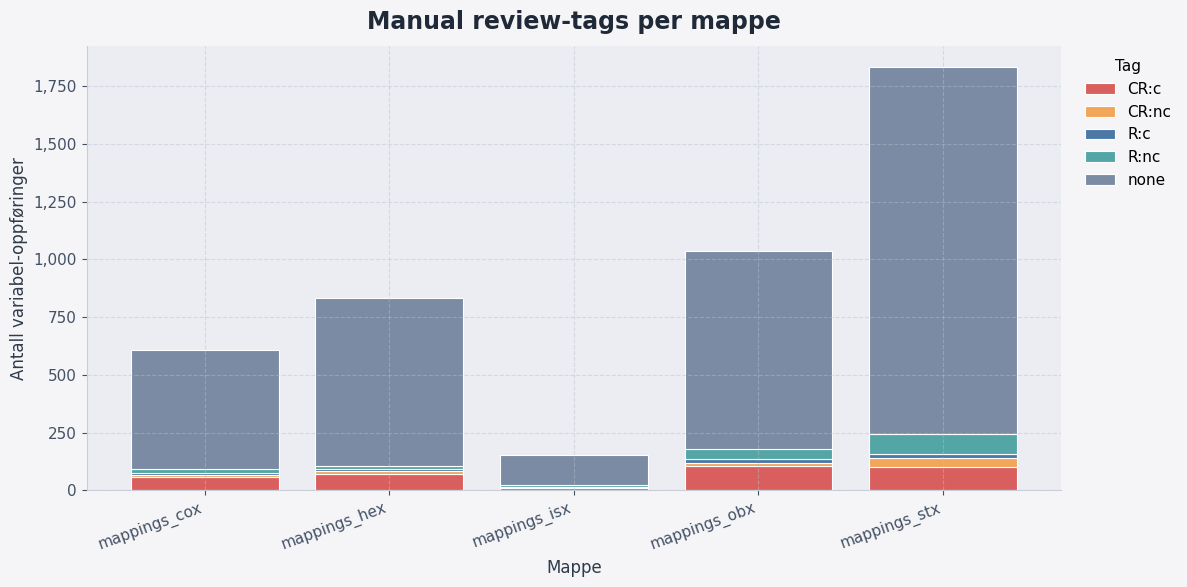

In [13]:
tag_order = ['CR:c', 'CR:nc', 'R:c', 'R:nc', 'none']
pivot = (
    df.groupby(['folder', 'tag'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=tag_order, fill_value=0)
)
fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(pivot))
for tag in tag_order:
    vals = pivot[tag].values
    ax.bar(pivot.index, vals, bottom=bottom, color=TAG_COLORS[tag], label=tag, edgecolor='white', linewidth=0.8)
    bottom += vals
ax.legend(title='Tag', bbox_to_anchor=(1.01, 1), loc='upper left')
style_axis(ax, 'Manual review-tags per mappe', xlabel='Mappe', ylabel='Antall variabel-oppføringer')
ax.set_xticklabels(pivot.index, rotation=20, ha='right')
fig.tight_layout()
fig.savefig(OUT_DIR / '1_tag_overview_per_folder.png', dpi=150)
plt.show()

## Plot 2 — Review-aktivitet per variabel og mappe (heatmap)

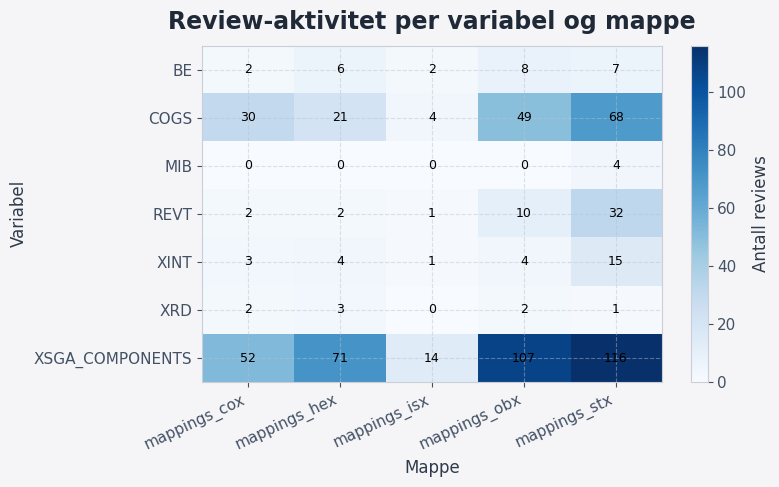

In [14]:
reviewed = df[df['has_review']].copy()
pivot2 = reviewed.groupby(['variable', 'folder']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(max(8, len(pivot2.columns)*1.5), max(5, len(pivot2)*0.6)))
if HAS_SEABORN:
    sns.heatmap(pivot2, annot=True, fmt='d', linewidths=0.5, cmap='Blues', ax=ax, cbar_kws={'label': 'Antall reviews'})
else:
    im = ax.imshow(pivot2.values, aspect='auto', cmap='Blues')
    ax.set_xticks(range(len(pivot2.columns)))
    ax.set_xticklabels(pivot2.columns, rotation=25, ha='right')
    ax.set_yticks(range(len(pivot2.index)))
    ax.set_yticklabels(pivot2.index)
    for i in range(len(pivot2.index)):
        for j in range(len(pivot2.columns)):
            ax.text(j, i, str(pivot2.values[i, j]), ha='center', va='center', fontsize=9)
    fig.colorbar(im, ax=ax, label='Antall reviews')
ax.set_title('Review-aktivitet per variabel og mappe', pad=12, fontsize=17, fontweight='bold')
ax.set_xlabel('Mappe')
ax.set_ylabel('Variabel')
fig.tight_layout()
fig.savefig(OUT_DIR / '2_review_heatmap_var_folder.png', dpi=150)
plt.show()

## Plot 3 — Fordeling av review-tags

- **CR:c / CR:nc** → unike selskaper (ett selskap telles én gang uansett antall flaggede variabler)
- **R:c / R:nc** → antall tilfeller (hvert enkelt sted review er gjort)

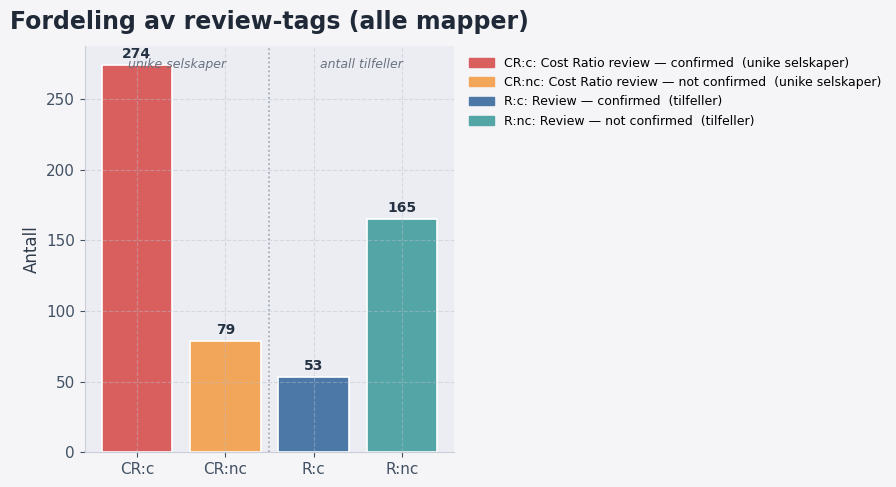

In [15]:
tag_order3 = ['CR:c', 'CR:nc', 'R:c', 'R:nc']
counts3 = {}
for tag in ['CR:c', 'CR:nc']:
    counts3[tag] = df[df['tag'] == tag]['company'].nunique()
for tag in ['R:c', 'R:nc']:
    counts3[tag] = int((df['tag'] == tag).sum())
values3 = [counts3[t] for t in tag_order3]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(tag_order3, values3, color=[TAG_COLORS[t] for t in tag_order3], edgecolor='white', linewidth=1.2)
add_bar_labels(ax)
style_axis(ax, 'Fordeling av review-tags (alle mapper)', ylabel='Antall')
ax.axvline(1.5, color='#9ca3af', linewidth=1.2, linestyle=':')

# Bruk transAxes (relative koordinater 0-1) for å unngå at get_ylim() gir feil verdi
ax.text(0.25, 0.97, 'unike selskaper', ha='center', va='top',
        fontsize=9, color='#6b7280', style='italic', transform=ax.transAxes)
ax.text(0.75, 0.97, 'antall tilfeller', ha='center', va='top',
        fontsize=9, color='#6b7280', style='italic', transform=ax.transAxes)

legend_info = {
    'CR:c':  'Cost Ratio review — confirmed  (unike selskaper)',
    'CR:nc': 'Cost Ratio review — not confirmed  (unike selskaper)',
    'R:c':   'Review — confirmed  (tilfeller)',
    'R:nc':  'Review — not confirmed  (tilfeller)',
}
patches = [mpatches.Patch(color=TAG_COLORS[t], label=f"{t}: {legend_info[t]}") for t in tag_order3]
ax.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / '3_tag_distribution.png', dpi=150)
plt.show()

/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_57515/2237175447.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


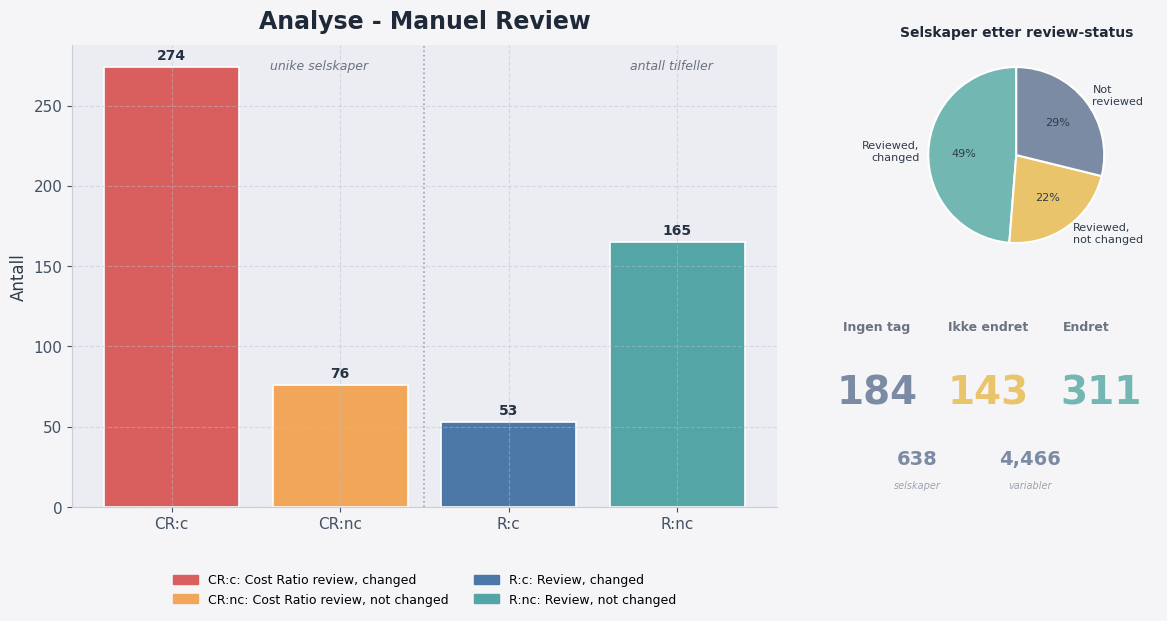

In [ ]:
tag_order3 = ['CR:c', 'CR:nc', 'R:c', 'R:nc']
counts3 = {}

# CR:c — unike selskaper med minst én CR:c-tag
cr_c_companies = set(df[df['tag'] == 'CR:c']['company'].unique())
counts3['CR:c'] = len(cr_c_companies)

# CR:nc — unike selskaper, men ekskluder selskaper som allerede er i CR:c
cr_nc_companies = set(df[df['tag'] == 'CR:nc']['company'].unique()) - cr_c_companies
counts3['CR:nc'] = len(cr_nc_companies)

# R:c og R:nc — antall tilfeller (rader)
for tag in ['R:c', 'R:nc']:
    counts3[tag] = int((df['tag'] == tag).sum())

# Ingen tag — kun selskaper som ALDRI har noen tag på tvers av alle mapper
no_tag_companies = len(set(df['company'].unique()) - set(df[df['tag'] != 'none']['company'].unique()))

# Totalt antall selskaper med minst én confirmed tag (CR:c eller R:c) — union, ingen dobbeltelling
r_c_companies       = set(df[df['tag'] == 'R:c']['company'].unique())
confirmed_companies = cr_c_companies | r_c_companies

# Reviewed, not changed — ekskl. selskaper som er i confirmed
not_changed_companies = len(
    set(df[df['tag'].isin(['CR:nc', 'R:nc'])]['company'].unique()) - confirmed_companies
)

# Sektordiagram-verdier
pie_values = [len(confirmed_companies), not_changed_companies, no_tag_companies]
pie_labels = ['Reviewed,\nchanged', 'Reviewed,\nnot changed', 'Not\nreviewed']
pie_colors = [PALETTE['green'], PALETTE['gold'], PALETTE['slate']]

values3 = [counts3[t] for t in tag_order3]

fig = plt.figure(figsize=(14, 6))
gs  = fig.add_gridspec(2, 2, width_ratios=[2.5, 1], height_ratios=[1, 1], hspace=0.1)

ax      = fig.add_subplot(gs[:, 0])
ax_pie  = fig.add_subplot(gs[0, 1])
ax_info = fig.add_subplot(gs[1, 1])

# ── Hovedplot (venstre) ────────────────────────────────────────────────────
ax.bar(tag_order3, values3, color=[TAG_COLORS[t] for t in tag_order3], edgecolor='white', linewidth=1.2)
add_bar_labels(ax)
style_axis(ax, 'Analyse - Manuel Review', ylabel='Antall')
ax.axvline(1.5, color='#9ca3af', linewidth=1.2, linestyle=':')
ax.text(0.35, 0.97, 'unike selskaper', ha='center', va='top',
        fontsize=9, color='#6b7280', style='italic', transform=ax.transAxes)
ax.text(0.85, 0.97, 'antall tilfeller', ha='center', va='top',
        fontsize=9, color='#6b7280', style='italic', transform=ax.transAxes)

legend_info = {
    'CR:c':  'Cost Ratio review, changed',
    'CR:nc': 'Cost Ratio review, not changed',
    'R:c':   'Review, changed',
    'R:nc':  'Review, not changed',
}
patches = [mpatches.Patch(color=TAG_COLORS[t], label=f"{t}: {legend_info[t]}") for t in tag_order3]
ax.legend(handles=patches, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=9)

# ── Sektordiagram (øvre høyre) ────────────────────────────────────────────
ax_pie.pie(
    pie_values, labels=pie_labels, colors=pie_colors,
    autopct='%1.0f%%', startangle=90,
    textprops={'fontsize': 8, 'color': '#2f3b4a'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)
ax_pie.set_title('Selskaper etter review-status', fontsize=10, fontweight='bold',
                 color='#1f2937', pad=6)

# ── Infoboks (nedre høyre) — tre kolonner ─────────────────────────────────
ax_info.axis('off')

total_companies  = len(set(df['company'].unique()))
total_variables  = len(df)

ax_info.text(0.005, 0.82, 'Ingen tag', ha='center', va='center',
             fontsize=9, fontweight='bold', color='#6b7280', transform=ax_info.transAxes)
ax_info.text(0.005, 0.52, f'{no_tag_companies:,}', ha='center', va='center',
             fontsize=28, fontweight='bold', color=PALETTE['slate'], transform=ax_info.transAxes)

ax_info.text(0.40, 0.82, 'Ikke endret', ha='center', va='center',
             fontsize=9, fontweight='bold', color='#6b7280', transform=ax_info.transAxes)
ax_info.text(0.40, 0.52, f'{not_changed_companies:,}', ha='center', va='center',
             fontsize=28, fontweight='bold', color=PALETTE['gold'], transform=ax_info.transAxes)

ax_info.text(0.75, 0.82, 'Endret', ha='center', va='center',
             fontsize=9, fontweight='bold', color='#6b7280', transform=ax_info.transAxes)
ax_info.text(0.80, 0.52, f'{len(confirmed_companies):,}', ha='center', va='center',
             fontsize=28, fontweight='bold', color=PALETTE['green'], transform=ax_info.transAxes)

# Mini-rad: selskaper og variabler
ax_info.text(0.15, 0.22, f'{total_companies:,}', ha='center', va='center',
             fontsize=14, fontweight='bold', color=PALETTE['slate'], transform=ax_info.transAxes)
ax_info.text(0.15, 0.10, 'selskaper', ha='center', va='center',
             fontsize=7, color='#9ca3af', style='italic', transform=ax_info.transAxes)

ax_info.text(0.55, 0.22, f'{total_variables:,}', ha='center', va='center',
             fontsize=14, fontweight='bold', color=PALETTE['slate'], transform=ax_info.transAxes)
ax_info.text(0.55, 0.10, 'variabler', ha='center', va='center',
             fontsize=7, color='#9ca3af', style='italic', transform=ax_info.transAxes)

for spine in ax_info.spines.values():
    spine.set_visible(False)
fig.tight_layout()
fig.savefig(OUT_DIR / '3_tag_distribution.png', dpi=150)
plt.show()

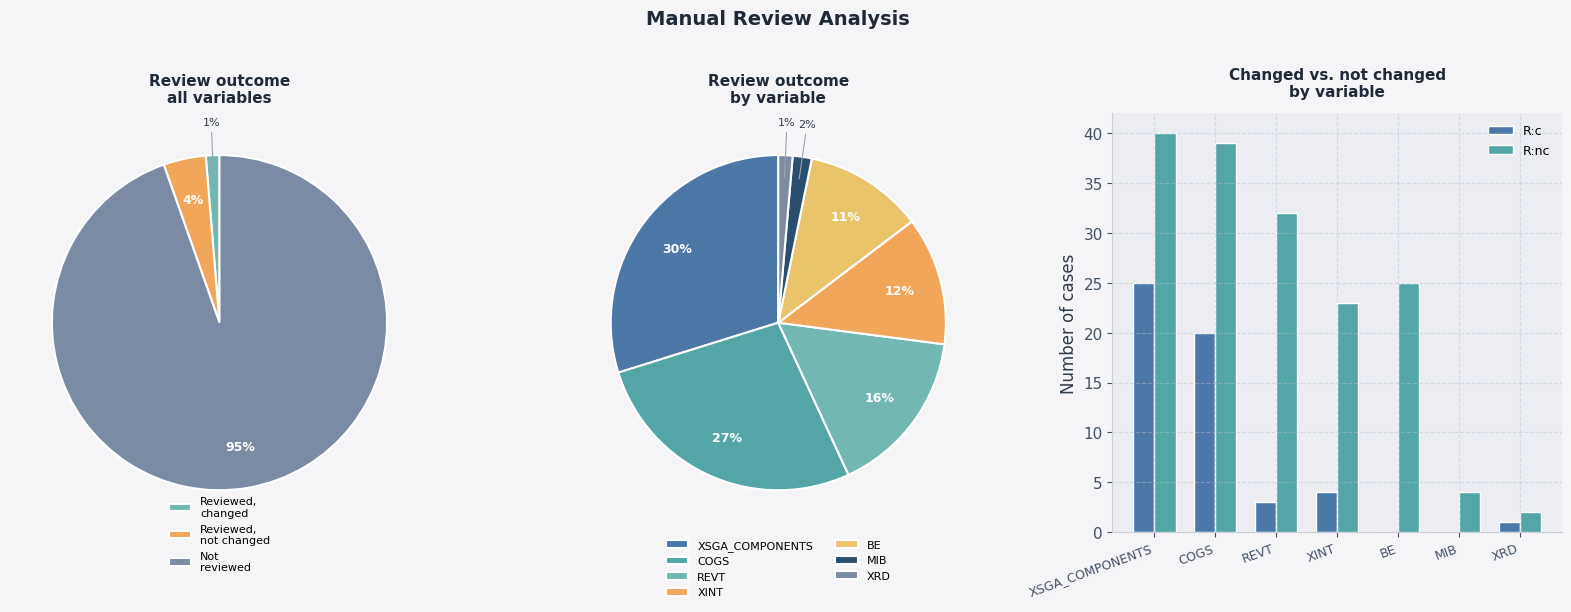

In [70]:
# ── Data ──────────────────────────────────────────────────────────────────
tag_priority = {'CR:c': 3, 'R:c': 2, 'CR:nc': 1, 'R:nc': 1, 'none': 0}
df['tag_rank'] = df['tag'].map(tag_priority)
top_tag = df.groupby(['company', 'variable'])['tag_rank'].max().reset_index()
top_tag['tag_group'] = top_tag['tag_rank'].map({
    3: 'changed', 2: 'changed', 1: 'not_changed', 0: 'not_reviewed'
})

# R-only version for first pie (exclude CR)
r_top = df[df['tag'].isin(['R:c', 'R:nc', 'none'])].copy()
r_top['tag_rank'] = r_top['tag'].map({'R:c': 2, 'R:nc': 1, 'none': 0})
r_top_tag = r_top.groupby(['company', 'variable'])['tag_rank'].max().reset_index()
r_top_tag['tag_group'] = r_top_tag['tag_rank'].map({
    2: 'changed', 1: 'not_changed', 0: 'not_reviewed'
})

changed_n      = int((r_top_tag['tag_group'] == 'changed').sum())
not_changed_n  = int((r_top_tag['tag_group'] == 'not_changed').sum())
not_reviewed_n = int((r_top_tag['tag_group'] == 'not_reviewed').sum())

pie1_values = [changed_n, not_changed_n, not_reviewed_n]
pie1_labels = ['Reviewed,\nchanged', 'Reviewed,\nnot changed', 'Not\nreviewed']
pie1_colors = [PALETTE['green'], PALETTE['orange'], PALETTE['slate']]

r_only = df[df['tag'].isin(['R:c', 'R:nc'])].copy()
r_var_counts = r_only.groupby(['variable', 'tag']).size().unstack(fill_value=0)
r_var_counts['total'] = r_var_counts.sum(axis=1)
r_var_counts = r_var_counts.sort_values('total', ascending=False)

pie2_values = r_var_counts.get('R:c', pd.Series(dtype=int)).reindex(r_var_counts.index, fill_value=0).values + \
              r_var_counts.get('R:nc', pd.Series(dtype=int)).reindex(r_var_counts.index, fill_value=0).values
pie2_labels = r_var_counts.index.tolist()
pie2_colors = [PALETTE['blue'], PALETTE['teal'], PALETTE['green'],
               PALETTE['orange'], PALETTE['gold'], PALETTE['navy'], PALETTE['slate']][:len(pie2_labels)]

r_c_per_var  = r_var_counts.get('R:c',  pd.Series(dtype=int)).reindex(r_var_counts.index, fill_value=0)
r_nc_per_var = r_var_counts.get('R:nc', pd.Series(dtype=int)).reindex(r_var_counts.index, fill_value=0)

# ── Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# ── Plot 1 ─────────────────────────────────────────────────────────────────
result1 = axes[0].pie(pie1_values, colors=pie1_colors, autopct=None, labels=None,
                      startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
wedges1 = result1[0]
total1  = sum(pie1_values)
threshold = 0.03
for wedge, val in zip(wedges1, pie1_values):
    pct   = val / total1
    angle = (wedge.theta1 + wedge.theta2) / 2
    rad   = np.deg2rad(angle)
    if pct >= threshold:
        t = axes[0].text(0.75*np.cos(rad), 0.75*np.sin(rad), f'{pct*100:.0f}%',
                         ha='center', va='center', fontsize=9, 
                         fontweight='semibold', zorder=10)
        t.set_color('white')
    else:
        axes[0].annotate(
            f'{pct*100:.0f}%',
            xy=(0.85*np.cos(rad), 0.85*np.sin(rad)),
            xytext=(1.2*np.cos(rad), 1.2*np.sin(rad)),
            ha='center', va='center', fontsize=8, color='#2f3b4a',
            arrowprops=dict(arrowstyle='-', color='#9ca3af', lw=0.8),
        )
axes[0].legend(labels=pie1_labels, loc='lower center', bbox_to_anchor=(0.5, -0.12),
               ncol=1, fontsize=8, frameon=False)
axes[0].set_title('Review outcome\nall variables', fontsize=11,
                  fontweight='bold', color='#1f2937', pad=8)

# ── Plot 2 ─────────────────────────────────────────────────────────────────
result2 = axes[1].pie(pie2_values, colors=pie2_colors, autopct=None, labels=None,
                      startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
wedges2 = result2[0]
total2  = sum(pie2_values)
threshold = 0.03
for wedge, val in zip(wedges2, pie2_values):
    pct   = val / total2
    angle = (wedge.theta1 + wedge.theta2) / 2
    rad   = np.deg2rad(angle)
    if pct >= threshold:
        t = axes[1].text(0.75*np.cos(rad), 0.75*np.sin(rad), f'{pct*100:.0f}%',
                         ha='center', va='center', fontsize=9, fontweight='semibold', zorder=10)
        t.set_color('white')
    else:
        axes[1].annotate(
            f'{pct*100:.0f}%',
            xy=(0.85*np.cos(rad), 0.85*np.sin(rad)),
            xytext=(1.2*np.cos(rad), 1.2*np.sin(rad)),
            ha='center', va='center', fontsize=8, color='#2f3b4a',
            arrowprops=dict(arrowstyle='-', color='#9ca3af', lw=0.8),
        )
axes[1].legend(labels=pie2_labels, loc='lower center', bbox_to_anchor=(0.5, -0.18),
               ncol=2, fontsize=8, frameon=False)
axes[1].set_title('Review outcome\nby variable', fontsize=11,
                  fontweight='bold', color='#1f2937', pad=8)
# ── Plot 3 ─────────────────────────────────────────────────────────────────
x     = np.arange(len(r_var_counts.index))
width = 0.35
axes[2].bar(x - width/2, r_c_per_var.values,  width, label='R:c',  color=PALETTE['blue'], edgecolor='white')
axes[2].bar(x + width/2, r_nc_per_var.values, width, label='R:nc', color=PALETTE['teal'], edgecolor='white')
style_axis(axes[2], 'Changed vs. not changed\nby variable', ylabel='Number of cases')
axes[2].title.set_fontsize(11)
axes[2].set_xticks(x)
axes[2].set_xticklabels(r_var_counts.index.tolist(), rotation=20, ha='right', fontsize=9)
axes[2].legend(fontsize=9)

fig.suptitle('Manual Review Analysis', fontsize=14, fontweight='bold', color='#1f2937', y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / '8_review_pie_analysis.png', dpi=150)
plt.show()

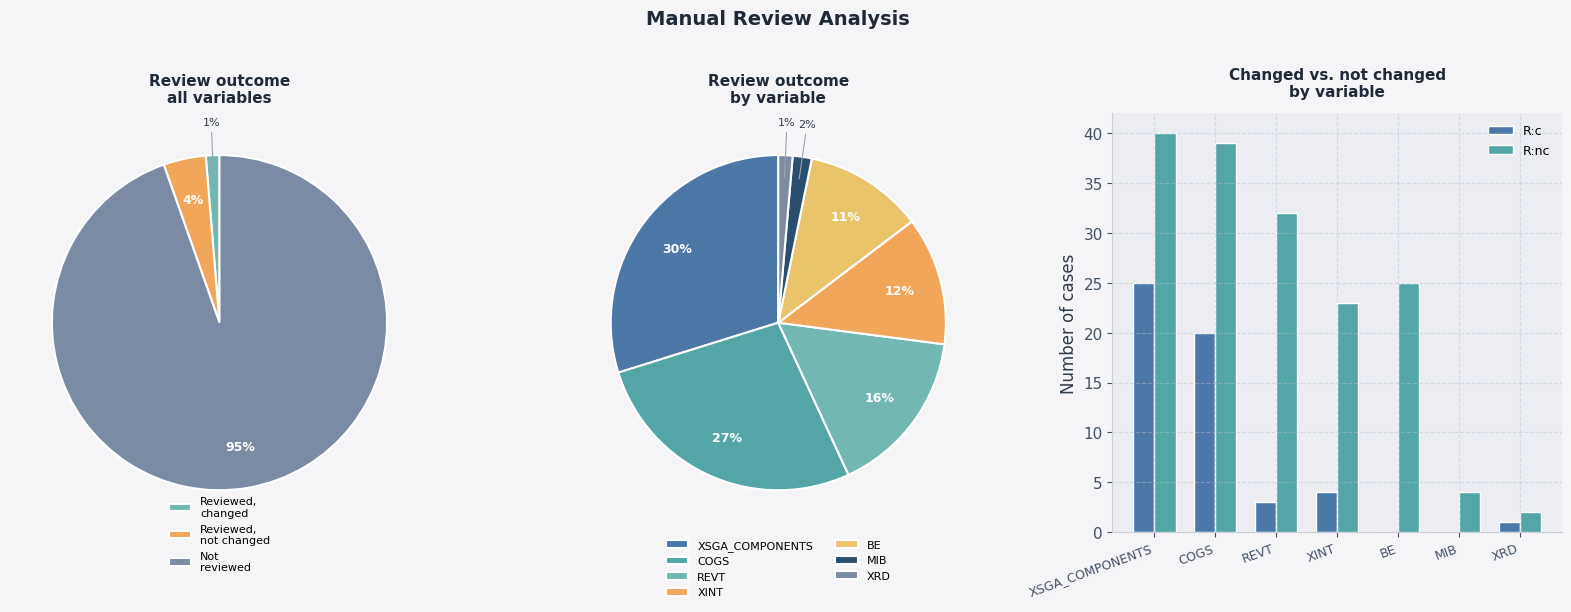

In [72]:
# ── Data ──────────────────────────────────────────────────────────────────
tag_priority = {'CR:c': 3, 'R:c': 2, 'CR:nc': 1, 'R:nc': 1, 'none': 0}
df['tag_rank'] = df['tag'].map(tag_priority)
top_tag = df.groupby(['company', 'variable'])['tag_rank'].max().reset_index()
top_tag['tag_group'] = top_tag['tag_rank'].map({
    3: 'changed', 2: 'changed', 1: 'not_changed', 0: 'not_reviewed'
})

# R-only version for first pie (exclude CR)
r_top = df[df['tag'].isin(['R:c', 'R:nc', 'none'])].copy()
r_top['tag_rank'] = r_top['tag'].map({'R:c': 2, 'R:nc': 1, 'none': 0})
r_top_tag = r_top.groupby(['company', 'variable'])['tag_rank'].max().reset_index()
r_top_tag['tag_group'] = r_top_tag['tag_rank'].map({
    2: 'changed', 1: 'not_changed', 0: 'not_reviewed'
})

changed_n      = int((r_top_tag['tag_group'] == 'changed').sum())
not_changed_n  = int((r_top_tag['tag_group'] == 'not_changed').sum())
not_reviewed_n = int((r_top_tag['tag_group'] == 'not_reviewed').sum())

pie1_values = [changed_n, not_changed_n, not_reviewed_n]
pie1_labels = ['Reviewed,\nchanged', 'Reviewed,\nnot changed', 'Not\nreviewed']
pie1_colors = [PALETTE['green'], PALETTE['orange'], PALETTE['slate']]

r_only = df[df['tag'].isin(['R:c', 'R:nc'])].copy()
r_var_counts = r_only.groupby(['variable', 'tag']).size().unstack(fill_value=0)
r_var_counts['total'] = r_var_counts.sum(axis=1)
r_var_counts = r_var_counts.sort_values('total', ascending=False)

pie2_values = r_var_counts.get('R:c', pd.Series(dtype=int)).reindex(r_var_counts.index, fill_value=0).values + \
              r_var_counts.get('R:nc', pd.Series(dtype=int)).reindex(r_var_counts.index, fill_value=0).values
pie2_labels = r_var_counts.index.tolist()
pie2_colors = [PALETTE['blue'], PALETTE['teal'], PALETTE['green'],
               PALETTE['orange'], PALETTE['gold'], PALETTE['navy'], PALETTE['slate']][:len(pie2_labels)]

r_c_per_var  = r_var_counts.get('R:c',  pd.Series(dtype=int)).reindex(r_var_counts.index, fill_value=0)
r_nc_per_var = r_var_counts.get('R:nc', pd.Series(dtype=int)).reindex(r_var_counts.index, fill_value=0)

# ── Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# ── Plot 1 ─────────────────────────────────────────────────────────────────
result1 = axes[0].pie(pie1_values, colors=pie1_colors, autopct=None, labels=None,
                      startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
wedges1 = result1[0]
total1  = sum(pie1_values)
threshold = 0.03
for wedge, val in zip(wedges1, pie1_values):
    pct   = val / total1
    angle = (wedge.theta1 + wedge.theta2) / 2
    rad   = np.deg2rad(angle)
    if pct >= threshold:
        t = axes[0].text(0.75*np.cos(rad), 0.75*np.sin(rad), f'{pct*100:.0f}%',
                         ha='center', va='center', fontsize=9, 
                         fontweight='semibold', zorder=10)
        t.set_color('white')
    else:
        axes[0].annotate(
            f'{pct*100:.0f}%',
            xy=(0.85*np.cos(rad), 0.85*np.sin(rad)),
            xytext=(1.2*np.cos(rad), 1.2*np.sin(rad)),
            ha='center', va='center', fontsize=8, color='#2f3b4a',
            arrowprops=dict(arrowstyle='-', color='#9ca3af', lw=0.8),
        )
axes[0].legend(labels=pie1_labels, loc='lower center', bbox_to_anchor=(0.5, -0.12),
               ncol=1, fontsize=8, frameon=False)
axes[0].set_title('Review outcome\nall variables', fontsize=11,
                  fontweight='bold', color='#1f2937', pad=8)

# ── Plot 2 ─────────────────────────────────────────────────────────────────
result2 = axes[1].pie(pie2_values, colors=pie2_colors, autopct=None, labels=None,
                      startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
wedges2 = result2[0]
total2  = sum(pie2_values)
threshold = 0.03
for wedge, val in zip(wedges2, pie2_values):
    pct   = val / total2
    angle = (wedge.theta1 + wedge.theta2) / 2
    rad   = np.deg2rad(angle)
    if pct >= threshold:
        t = axes[1].text(0.75*np.cos(rad), 0.75*np.sin(rad), f'{pct*100:.0f}%',
                         ha='center', va='center', fontsize=9, fontweight='semibold', zorder=10)
        t.set_color('white')
    else:
        axes[1].annotate(
            f'{pct*100:.0f}%',
            xy=(0.85*np.cos(rad), 0.85*np.sin(rad)),
            xytext=(1.2*np.cos(rad), 1.2*np.sin(rad)),
            ha='center', va='center', fontsize=8, color='#2f3b4a',
            arrowprops=dict(arrowstyle='-', color='#9ca3af', lw=0.8),
        )
axes[1].legend(labels=pie2_labels, loc='lower center', bbox_to_anchor=(0.5, -0.18),
               ncol=2, fontsize=8, frameon=False)
axes[1].set_title('Review outcome\nby variable', fontsize=11,
                  fontweight='bold', color='#1f2937', pad=8)
# ── Plot 3 ─────────────────────────────────────────────────────────────────
x     = np.arange(len(r_var_counts.index))
width = 0.35
axes[2].bar(x - width/2, r_c_per_var.values,  width, label='R:c',  color=PALETTE['blue'], edgecolor='white')
axes[2].bar(x + width/2, r_nc_per_var.values, width, label='R:nc', color=PALETTE['teal'], edgecolor='white')
style_axis(axes[2], 'Changed vs. not changed\nby variable', ylabel='Number of cases')
axes[2].title.set_fontsize(11)
axes[2].set_xticks(x)
axes[2].set_xticklabels(r_var_counts.index.tolist(), rotation=20, ha='right', fontsize=9)
axes[2].legend(fontsize=9)

fig.suptitle('Manual Review Analysis', fontsize=14, fontweight='bold', color='#1f2937', y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / '8_review_pie_analysis.png', dpi=150)
plt.show()

## Plot 4 — Andel selskaper med minst én review-tag per mappe

/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_57515/3854841996.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(pct.index, rotation=20, ha='right')


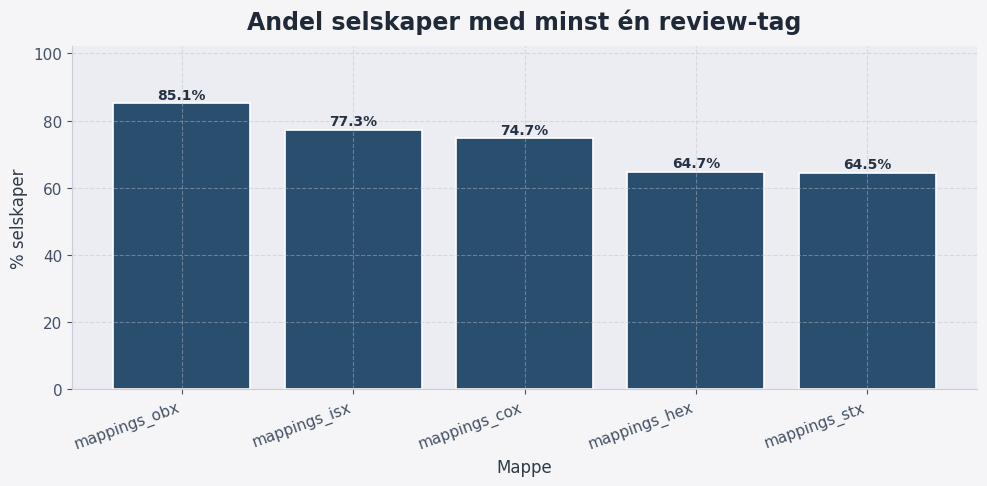

In [68]:
reviewed_per_folder = df[df['has_review']].groupby('folder')['company'].nunique()
total_per_folder    = df.groupby('folder')['company'].nunique()
pct = (reviewed_per_folder / total_per_folder * 100).fillna(0).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pct.index, pct.values, color=PALETTE['navy'], edgecolor='white', linewidth=1.2)
for patch, val in zip(ax.patches, pct.values):
    ax.text(patch.get_x() + patch.get_width()/2, val+0.5, f'{val:.1f}%',
            ha='center', va='bottom', fontsize=10, color='#253243', fontweight='semibold')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))
style_axis(ax, 'Andel selskaper med minst én review-tag', xlabel='Mappe', ylabel='% selskaper')
ax.set_xticklabels(pct.index, rotation=20, ha='right')
ax.set_ylim(0, min(pct.max()*1.2, 110))
fig.tight_layout()
fig.savefig(OUT_DIR / '4_review_rate_per_folder.png', dpi=150)
plt.show()

## Plot 5 — CR:c severity-fordeling

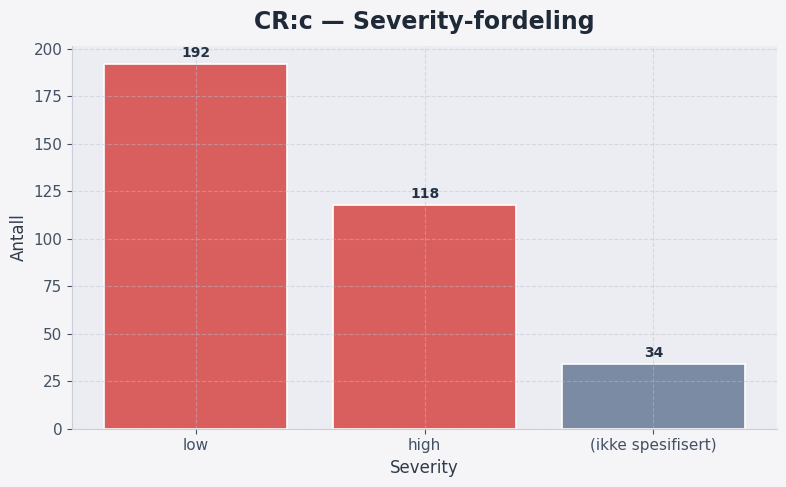

In [17]:
cr_c = df[df['tag'] == 'CR:c'].copy()
if cr_c.empty:
    print('Ingen CR:c-tags — hopper over.')
else:
    severity_counts = cr_c['cr_severity'].fillna('(ikke spesifisert)').value_counts()
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = [PALETTE['red'] if s != '(ikke spesifisert)' else PALETTE['slate'] for s in severity_counts.index]
    ax.bar(severity_counts.index, severity_counts.values, color=colors, edgecolor='white', linewidth=1.2)
    add_bar_labels(ax)
    style_axis(ax, 'CR:c — Severity-fordeling', xlabel='Severity', ylabel='Antall')
    fig.tight_layout()
    fig.savefig(OUT_DIR / '5_cr_severity.png', dpi=150)
    plt.show()

## Plot 6 — Max kandidat-confidence etter review-tag (boxplot)

/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_57515/1347082420.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_groups, labels=tag_order6, patch_artist=True)


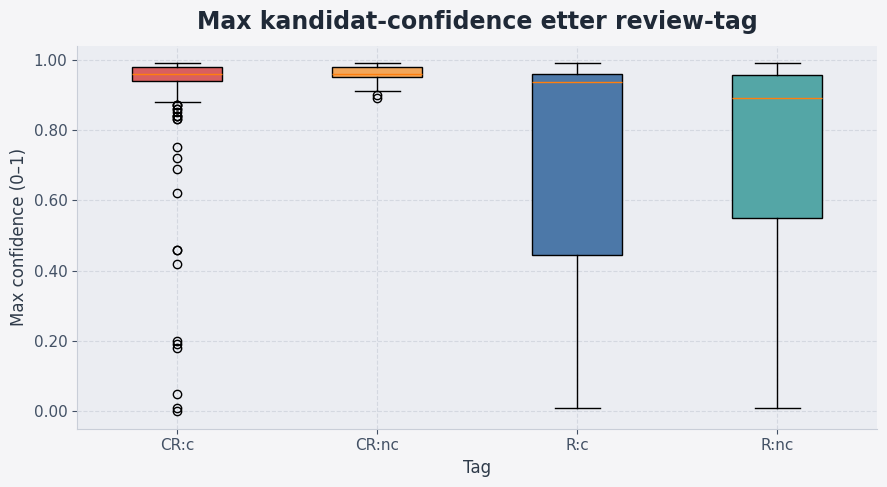

In [18]:
sub = df[df['max_confidence'].notna() & (df['tag'] != 'none')].copy()
if sub.empty:
    print('Ikke nok data — hopper over.')
else:
    tag_order6 = [t for t in ['CR:c', 'CR:nc', 'R:c', 'R:nc'] if t in sub['tag'].unique()]
    fig, ax = plt.subplots(figsize=(9, 5))
    if HAS_SEABORN:
        sns.boxplot(data=sub, x='tag', y='max_confidence', order=tag_order6,
                    palette={t: TAG_COLORS[t] for t in tag_order6}, ax=ax, linewidth=1.5, fliersize=4)
    else:
        data_groups = [sub[sub['tag'] == t]['max_confidence'].values for t in tag_order6]
        bp = ax.boxplot(data_groups, labels=tag_order6, patch_artist=True)
        for patch, tag in zip(bp['boxes'], tag_order6):
            patch.set_facecolor(TAG_COLORS[tag])
    style_axis(ax, 'Max kandidat-confidence etter review-tag', xlabel='Tag', ylabel='Max confidence (0–1)')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))
    fig.tight_layout()
    fig.savefig(OUT_DIR / '6_confidence_by_tag.png', dpi=150)
    plt.show()

## Plot 7 — Top-N selskaper etter antall review-tags

/var/folders/6l/ncl3jvl12ks8dlc1p950qzsh0000gn/T/ipykernel_57515/3245376114.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top.index, rotation=35, ha='right', fontsize=9)


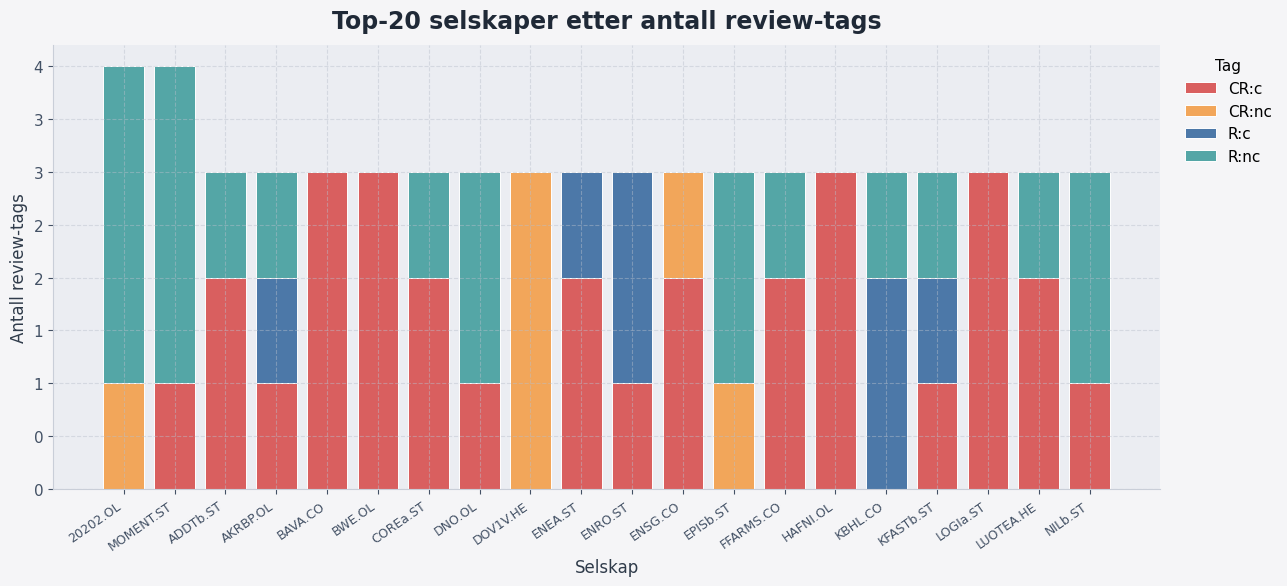

In [19]:
reviewed7 = df[df['has_review']].copy()
if reviewed7.empty:
    print('Ingen review-tags — hopper over.')
else:
    counts7 = reviewed7.groupby(['company', 'tag']).size().unstack(fill_value=0)
    tag_order7 = [t for t in ['CR:c', 'CR:nc', 'R:c', 'R:nc'] if t in counts7.columns]
    counts7['total'] = counts7[tag_order7].sum(axis=1)
    top = counts7.nlargest(TOP_N, 'total')[tag_order7]
    fig, ax = plt.subplots(figsize=(13, 6))
    bottom = np.zeros(len(top))
    for tag in tag_order7:
        ax.bar(top.index, top[tag].values, bottom=bottom, color=TAG_COLORS[tag],
               label=tag, edgecolor='white', linewidth=0.7)
        bottom += top[tag].values
    ax.legend(title='Tag', bbox_to_anchor=(1.01, 1), loc='upper left')
    style_axis(ax, f'Top-{TOP_N} selskaper etter antall review-tags', xlabel='Selskap', ylabel='Antall review-tags')
    ax.set_xticklabels(top.index, rotation=35, ha='right', fontsize=9)
    fig.tight_layout()
    fig.savefig(OUT_DIR / '7_top_companies_by_reviews.png', dpi=150)
    plt.show()

In [87]:
import json
import re
from pathlib import Path
from collections import defaultdict

# ── Config ─────────────────────────────────────────────────────────────────
ROOT = Path("../data/mappings/prof_mappings")

INCLUDE_FOLDERS = {"mappings_cox", "mappings_hex", "mappings_isx",
                   "mappings_obx", "mappings_stx"}

EXCHANGE_NAMES = {
    'mappings_obx': 'Oslo Børs',
    'mappings_stx': 'Nasdaq Stockholm',
    'mappings_isx': 'Nasdaq Iceland',
    'mappings_cox': 'Nasdaq Copenhagen',
    'mappings_hex': 'Nasdaq Helsinki'
}

TARGET_TAGS = [
    'CR:c|low|double',
    'CR:c|high|double',
    'CR:c||double',
    'CR:c|low|missing',
    'CR:c|high|missing',
    'CR:c||missing',
    'CR:c|low|misclassified',
    'CR:c|high|misclassified',
    'CR:c||misclassified',
    'CR:nc',
    'R:c',
    'R:nc',
    'OI:c',
    'OI:nc',
]

# ── Exact tag matching — avoids substring false positives ─────────────────
def find_tags(notes, target_tags):
    matched = []
    for tag in target_tags:
        pattern = r'(?<![A-Za-z:])' + re.escape(tag) + r'(?![A-Za-z:|])'
        if re.search(pattern, notes):
            matched.append(tag)
    return matched

# ── Priority logic ─────────────────────────────────────────────────────────
# Priority hierarchy (highest to lowest):
# 1. CR:c  — suppresses R:c, R:nc, OI:c, OI:nc, CR:nc
# 2. R:c   — suppresses OI:c, OI:nc, R:nc
# 3. OI:c  — suppresses CR:nc, OI:nc
# 4. CR:nc — suppresses nothing
# Principle: :c always beats :nc

def apply_priority(matched):
    has_cr_c = any(t.startswith('CR:c') for t in matched)
    has_r_c  = 'R:c' in matched
    has_oi_c = 'OI:c' in matched

    if has_cr_c:
        return [t for t in matched
                if t not in ('R:c', 'R:nc', 'OI:c', 'OI:nc', 'CR:nc')]
    elif has_r_c:
        return [t for t in matched
                if t not in ('OI:c', 'OI:nc', 'R:nc')]
    elif has_oi_c:
        return [t for t in matched
                if t not in ('CR:nc', 'OI:nc')]
    return matched

# ── Count with priority logic per exchange ─────────────────────────────────
counts_total = {tag: 0 for tag in TARGET_TAGS}
counts_per_exchange = {ex: {tag: 0 for tag in TARGET_TAGS}
                       for ex in EXCHANGE_NAMES.values()}

remaining_multi = []

for folder in ROOT.iterdir():
    if not folder.is_dir() or folder.name not in INCLUDE_FOLDERS:
        continue
    exchange = EXCHANGE_NAMES[folder.name]
    for jf in folder.rglob('*.json'):
        try:
            data = json.loads(jf.read_text(encoding='utf-8'))
        except Exception:
            continue
        for var_obj in data.get('variables', []):
            notes = var_obj.get('notes', '') or ''
            matched = find_tags(notes, TARGET_TAGS)

            if not matched:
                continue

            matched = apply_priority(matched)

            if len(matched) > 1:
                remaining_multi.append({
                    'folder': folder.name,
                    'file': jf.stem,
                    'variable': var_obj.get('variable', ''),
                    'matched_tags': matched,
                    'notes': notes[:300]
                })

            for tag in matched:
                counts_total[tag] += 1
                counts_per_exchange[exchange][tag] += 1

# ── Print total ────────────────────────────────────────────────────────────
print("=" * 55)
print("FULL TAG COUNTS — TOTAL")
print(f"{'Tag':<35} {'Count':>8}")
print('-' * 45)
for tag, count in counts_total.items():
    print(f"{tag:<35} {count:>8}")
print('-' * 45)
print(f"{'Total':<35} {sum(counts_total.values()):>8}")

# ── Print per exchange ─────────────────────────────────────────────────────
exchanges = list(EXCHANGE_NAMES.values())
col_w = 14

print()
print("=" * (35 + col_w * (len(exchanges) + 1)))
print("FULL TAG COUNTS — PER EXCHANGE")
print()
header = f"{'Tag':<35}" + "".join(f"{ex:>{col_w}}" for ex in exchanges) + f"{'Total':>{col_w}}"
print(header)
print('-' * (35 + col_w * (len(exchanges) + 1)))
for tag in TARGET_TAGS:
    row_total = sum(counts_per_exchange[ex][tag] for ex in exchanges)
    row = f"{tag:<35}" + "".join(f"{counts_per_exchange[ex][tag]:>{col_w}}"
                                  for ex in exchanges) + f"{row_total:>{col_w}}"
    print(row)
print('-' * (35 + col_w * (len(exchanges) + 1)))
grand_total = sum(counts_total.values())
totals = f"{'Total':<35}" + "".join(
    f"{sum(counts_per_exchange[ex][tag] for tag in TARGET_TAGS):>{col_w}}"
    for ex in exchanges) + f"{grand_total:>{col_w}}"
print(totals)

# ── Verification ───────────────────────────────────────────────────────────
cr_c_subgroup_sum = sum(counts_total[t] for t in TARGET_TAGS if t.startswith('CR:c'))
print()
print("=" * 55)
print("VERIFICATION")
print(f"  Sum of CR:c subgroups:          {cr_c_subgroup_sum:>6}")
print(f"  CR:nc count:                    {counts_total['CR:nc']:>6}")
print(f"  R:c  (excl. overlaps):          {counts_total['R:c']:>6}")
print(f"  R:nc (excl. overlaps):          {counts_total['R:nc']:>6}")
print(f"  OI:c (excl. overlaps):          {counts_total['OI:c']:>6}")
print(f"  OI:nc (excl. overlaps):         {counts_total['OI:nc']:>6}")
print()
print(f"  Remaining multi-tag cases:      {len(remaining_multi):>6}",
      "✅" if len(remaining_multi) == 0 else "⚠️  — sjekk nedenfor")

if remaining_multi:
    print()
    for case in remaining_multi[:10]:
        print(f"    {case['folder']} | {case['file']} | {case['variable']}")
        print(f"    Tags:  {case['matched_tags']}")
        print(f"    Notes: {case['notes']}")
        print()
    if len(remaining_multi) > 10:
        print(f"  ... og {len(remaining_multi) - 10} flere tilfeller")

FULL TAG COUNTS — TOTAL
Tag                                    Count
---------------------------------------------
CR:c|low|double                           18
CR:c|high|double                          52
CR:c||double                              16
CR:c|low|missing                         104
CR:c|high|missing                         30
CR:c||missing                             12
CR:c|low|misclassified                    69
CR:c|high|misclassified                   36
CR:c||misclassified                        6
CR:nc                                      0
R:c                                       56
R:nc                                     172
OI:c                                      12
OI:nc                                      0
---------------------------------------------
Total                                    583

FULL TAG COUNTS — PER EXCHANGE

Tag                                     Oslo BørsNasdaq StockholmNasdaq IcelandNasdaq CopenhagenNasdaq Helsinki         Total
-----

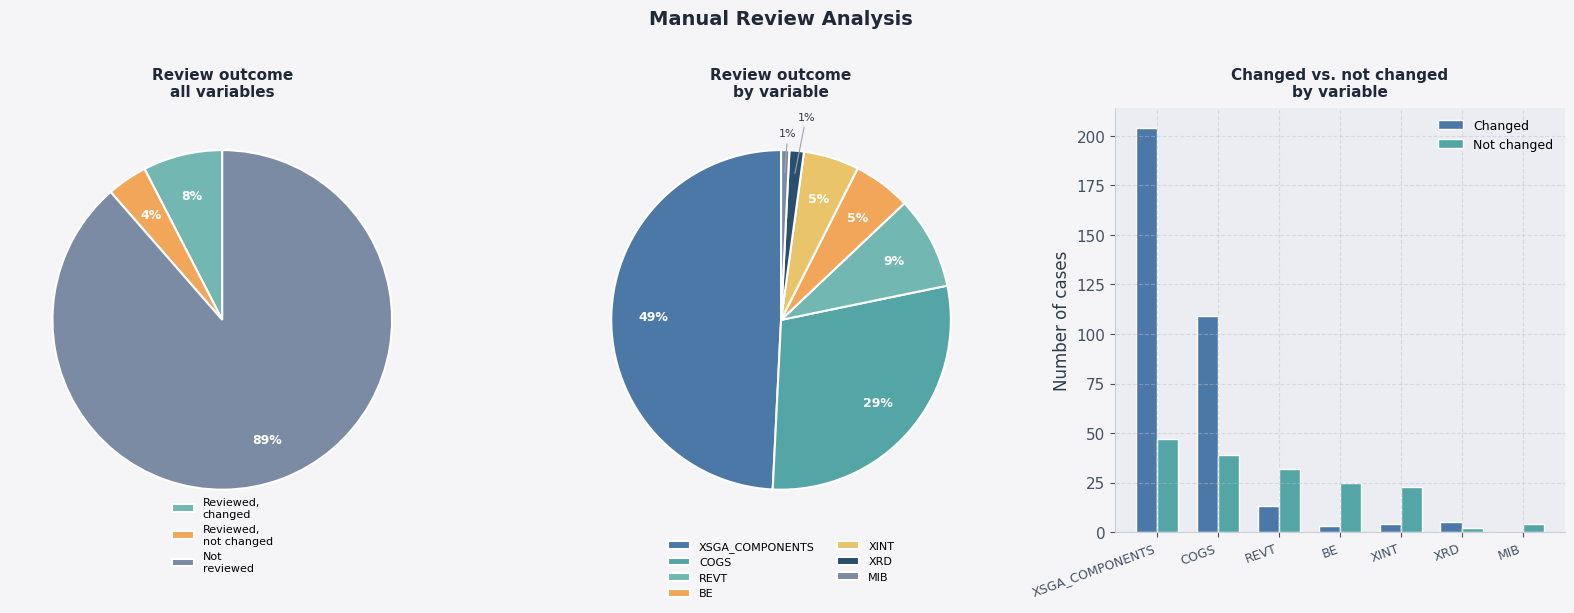

Total observations:                4466
Reviewed, changed (adj):            338
Reviewed, not changed:              172
Not reviewed:                      3956
XSGA_COMPONENTS           theta1=90.0  theta2=267.2  mid=178.6
COGS                      theta1=267.2  theta2=371.6  mid=319.4
REVT                      theta1=371.6  theta2=403.4  mid=387.5
BE                        theta1=403.4  theta2=423.2  mid=413.3
XINT                      theta1=423.2  theta2=442.2  mid=432.7
XRD                       theta1=442.2  theta2=447.2  mid=444.7
MIB                       theta1=447.2  theta2=450.0  mid=448.6


In [ ]:
import numpy as np
from matplotlib import gridspec

# ── Konstanter ─────────────────────────────────────────────────────────────
N_COMPANIES  = 638
N_VARIABLES  = 7
TOTAL_OBS    = N_COMPANIES * N_VARIABLES  # 4,466

MISSING_TAGS = ['CR:c|low|missing', 'CR:c|high|missing', 'CR:c||missing']
VARIABLES    = ['REVT', 'COGS', 'XSGA_COMPONENTS', 'XRD', 'XINT', 'BE', 'MIB']

# ── Rebuild per-variable counts from JSON ──────────────────────────────────
var_counts_c  = {v: 0.0 for v in VARIABLES}
var_counts_nc = {v: 0   for v in VARIABLES}

ROOT_PATH = Path("../data/mappings/prof_mappings")

for folder in ROOT_PATH.iterdir():
    if not folder.is_dir() or folder.name not in INCLUDE_FOLDERS:
        continue
    for jf in folder.rglob('*.json'):
        try:
            data = json.loads(jf.read_text(encoding='utf-8'))
        except Exception:
            continue
        for var_obj in data.get('variables', []):
            notes    = var_obj.get('notes', '') or ''
            variable = var_obj.get('variable', '')
            if variable not in VARIABLES:
                continue
            matched = find_tags(notes, TARGET_TAGS)
            if not matched:
                continue
            matched = apply_priority(matched)
            for tag in matched:
                is_missing = tag in MISSING_TAGS
                if tag.startswith('CR:c') or tag in ('R:c', 'OI:c'):
                    var_counts_c[variable] += 0.5 if is_missing else 1.0
                elif tag in ('CR:nc', 'R:nc', 'OI:nc'):
                    var_counts_nc[variable] += 1

var_counts_c = {v: round(val) for v, val in var_counts_c.items()}

# ── Totaler ────────────────────────────────────────────────────────────────
sum_c_adj    = sum(var_counts_c.values())
sum_nc       = sum(var_counts_nc.values())
not_reviewed = TOTAL_OBS - sum_c_adj - sum_nc

# ── Diagram data ───────────────────────────────────────────────────────────
pie1_values = [sum_c_adj, sum_nc, not_reviewed]
pie1_labels = ['Reviewed,\nchanged', 'Reviewed,\nnot changed', 'Not\nreviewed']
pie1_colors = [PALETTE['green'], PALETTE['orange'], PALETTE['slate']]

var_totals  = {v: var_counts_c[v] + var_counts_nc[v] for v in VARIABLES}
var_sorted  = sorted(var_totals, key=var_totals.get, reverse=True)
pie2_values = [var_totals[v] for v in var_sorted]
pie2_labels = var_sorted
pie2_colors = [PALETTE['blue'], PALETTE['teal'], PALETTE['green'],
               PALETTE['orange'], PALETTE['gold'], PALETTE['navy'],
               PALETTE['slate']][:len(var_sorted)]

r_c_per_var  = pd.Series({v: var_counts_c[v]  for v in var_sorted})
r_nc_per_var = pd.Series({v: var_counts_nc[v] for v in var_sorted})

# ── Hardcoded xytext positions for small slices in pie2 ────────────────────
SMALL_SLICE_POS = {
    'XRD': (1.5, 0.35),
    'MIB': (1.5, -0.1),
}

# ── Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

threshold = 0.03

# ── Plot 1 ─────────────────────────────────────────────────────────────────
result1 = axes[0].pie(pie1_values, colors=pie1_colors, autopct=None, labels=None,
                      startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
wedges1 = result1[0]
total1  = sum(pie1_values)
for wedge, val in zip(wedges1, pie1_values):
    pct   = val / total1
    angle = (wedge.theta1 + wedge.theta2) / 2
    rad   = np.deg2rad(angle)
    if pct >= threshold:
        t = axes[0].text(0.75*np.cos(rad), 0.75*np.sin(rad), f'{pct*100:.0f}%',
                         ha='center', va='center', fontsize=9,
                         fontweight='semibold', zorder=10)
        t.set_color('white')
    else:
        axes[0].annotate(
            f'{pct*100:.0f}%',
            xy=(0.85*np.cos(rad), 0.85*np.sin(rad)),
            xytext=(1.2*np.cos(rad), 1.2*np.sin(rad)),
            ha='center', va='center', fontsize=8, color='#2f3b4a',
            arrowprops=dict(arrowstyle='-', color='#9ca3af', lw=0.8),
        )
axes[0].legend(labels=pie1_labels, loc='lower center', bbox_to_anchor=(0.5, -0.12),
               ncol=1, fontsize=8, frameon=False)
axes[0].set_title('Review outcome\nall variables', fontsize=11,
                  fontweight='bold', color='#1f2937', pad=8)

# ── Plot 2 ─────────────────────────────────────────────────────────────────
SMALL_SLICE_POS = {
    'XRD': (1.6 * np.cos(np.deg2rad(444.7)), 1.0 * np.sin(np.deg2rad(444.7)) + 0.2),
    'MIB': (1.6 * np.cos(np.deg2rad(448.6)), 1.25 * np.sin(np.deg2rad(448.6)) - 0.2),
}

result2 = axes[1].pie(pie2_values, colors=pie2_colors, autopct=None, labels=None,
                      startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
wedges2 = result2[0]
total2  = sum(pie2_values)
for label, wedge, val in zip(pie2_labels, wedges2, pie2_values):
    pct   = val / total2
    angle = (wedge.theta1 + wedge.theta2) / 2
    rad   = np.deg2rad(angle)
    if pct >= threshold:
        t = axes[1].text(0.75*np.cos(rad), 0.75*np.sin(rad), f'{pct*100:.0f}%',
                         ha='center', va='center', fontsize=9,
                         fontweight='semibold', zorder=10)
        t.set_color('white')
    else:
        if label in SMALL_SLICE_POS:
            xt, yt = SMALL_SLICE_POS[label]
        else:
            xt = 1.2 * np.cos(rad)
            yt = 1.2 * np.sin(rad)
        axes[1].annotate(
            f'{pct*100:.0f}%',
            xy=(0.85*np.cos(rad), 0.85*np.sin(rad)),
            xytext=(xt, yt),
            ha='center', va='center', fontsize=8, color='#2f3b4a',
            arrowprops=dict(arrowstyle='-', color='#9ca3af', lw=0.8),
        )
axes[1].legend(labels=pie2_labels, loc='lower center', bbox_to_anchor=(0.5, -0.18),
               ncol=2, fontsize=8, frameon=False)
axes[1].set_title('Review outcome\nby variable', fontsize=11,
                  fontweight='bold', color='#1f2937', pad=8)

# ── Plot 3 ─────────────────────────────────────────────────────────────────
x     = np.arange(len(var_sorted))
width = 0.35
axes[2].bar(x - width/2, r_c_per_var.values,  width, label='Changed',
            color=PALETTE['blue'], edgecolor='white')
axes[2].bar(x + width/2, r_nc_per_var.values, width, label='Not changed',
            color=PALETTE['teal'], edgecolor='white')
style_axis(axes[2], '', ylabel='Number of cases')
axes[2].set_title('Changed vs. not changed\nby variable', fontsize=11,
                  fontweight='bold', color='#1f2937', pad=8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(var_sorted, rotation=20, ha='right', fontsize=9)
axes[2].legend(fontsize=9)

fig.suptitle('Manual Review Analysis', fontsize=14, fontweight='bold', color='#1f2937', y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / '8_review_pie_analysis.png', dpi=150)
plt.show()

# ── Print summary ──────────────────────────────────────────────────────────
print(f"Total observations:              {TOTAL_OBS:>6}")
print(f"Reviewed, changed (adj):         {sum_c_adj:>6}")
print(f"Reviewed, not changed:           {sum_nc:>6}")
print(f"Not reviewed:                    {not_reviewed:>6}")

for label, wedge in zip(pie2_labels, wedges2):
    angle = (wedge.theta1 + wedge.theta2) / 2
    print(f"{label:<25} theta1={wedge.theta1:.1f}  theta2={wedge.theta2:.1f}  mid={angle:.1f}")

In [89]:
import re

def find_tags(notes, target_tags):
    matched = []
    for tag in target_tags:
        pattern = r'(?<![A-Za-z:])' + re.escape(tag) + r'(?![A-Za-z:|])'
        if re.search(pattern, notes):
            matched.append(tag)
    return matched

def apply_priority(matched):
    has_cr_c = any(t.startswith('CR:c') for t in matched)
    has_r_c  = 'R:c' in matched
    has_oi_c = 'OI:c' in matched

    if has_cr_c:
        return [t for t in matched
                if t not in ('R:c', 'R:nc', 'OI:c', 'OI:nc', 'CR:nc')]
    elif has_r_c:
        return [t for t in matched
                if t not in ('OI:c', 'OI:nc', 'R:nc')]
    elif has_oi_c:
        return [t for t in matched
                if t not in ('CR:nc', 'OI:nc')]
    return matched

# ── Validation ─────────────────────────────────────────────────────────────
multi_tag_cases = []

for folder in ROOT.iterdir():
    if not folder.is_dir() or folder.name not in INCLUDE_FOLDERS:
        continue
    for jf in folder.rglob('*.json'):
        try:
            data = json.loads(jf.read_text(encoding='utf-8'))
        except Exception:
            continue
        for var_obj in data.get('variables', []):
            notes = var_obj.get('notes', '') or ''
            matched = find_tags(notes, TARGET_TAGS)

            if not matched:
                continue

            matched = apply_priority(matched)

            if len(matched) > 1:
                multi_tag_cases.append({
                    'file': jf.stem,
                    'folder': folder.name,
                    'variable': var_obj.get('variable', ''),
                    'matched_tags': matched,
                    'notes': notes[:300]
                })

# ── Print results ──────────────────────────────────────────────────────────
print(f"Gjenstående tilfeller med flere tags etter prioritetslogikk: {len(multi_tag_cases)}",
      "✅" if len(multi_tag_cases) == 0 else "⚠️")
for case in multi_tag_cases[:20]:
    print(f"\n  {case['folder']} | {case['file']} | {case['variable']}")
    print(f"  Tags:  {case['matched_tags']}")
    print(f"  Notes: {case['notes']}")
if len(multi_tag_cases) > 20:
    print(f"\n... og {len(multi_tag_cases) - 20} flere tilfeller")

Gjenstående tilfeller med flere tags etter prioritetslogikk: 0 ✅


In [90]:
# ── Summary statistics ─────────────────────────────────────────────────────

MISSING_TAGS = ['CR:c|low|missing', 'CR:c|high|missing', 'CR:c||missing']

# Sum of all :c tags
sum_c = sum(counts_total[t] for t in TARGET_TAGS if t.endswith(':c') or ':c|' in t)

# Sum of all :c tags with missing weighted 0.5
missing_c = sum(counts_total[t] for t in MISSING_TAGS)
non_missing_c = sum_c - missing_c
sum_c_adjusted = non_missing_c + round(missing_c * 0.5)

# Sum of all :nc tags
sum_nc = sum(counts_total[t] for t in TARGET_TAGS if t.endswith(':nc') or ':nc|' in t)

print("=" * 55)
print("SUMMARY")
print(f"  Sum all :c (raw):               {sum_c:>6}")
print(f"    of which missing:             {missing_c:>6}")
print(f"  Sum all :c (missing * 0.5):     {sum_c_adjusted:>6}")
print(f"  Sum all :nc:                    {sum_nc:>6}")

SUMMARY
  Sum all :c (raw):                  411
    of which missing:                146
  Sum all :c (missing * 0.5):        338
  Sum all :nc:                       172


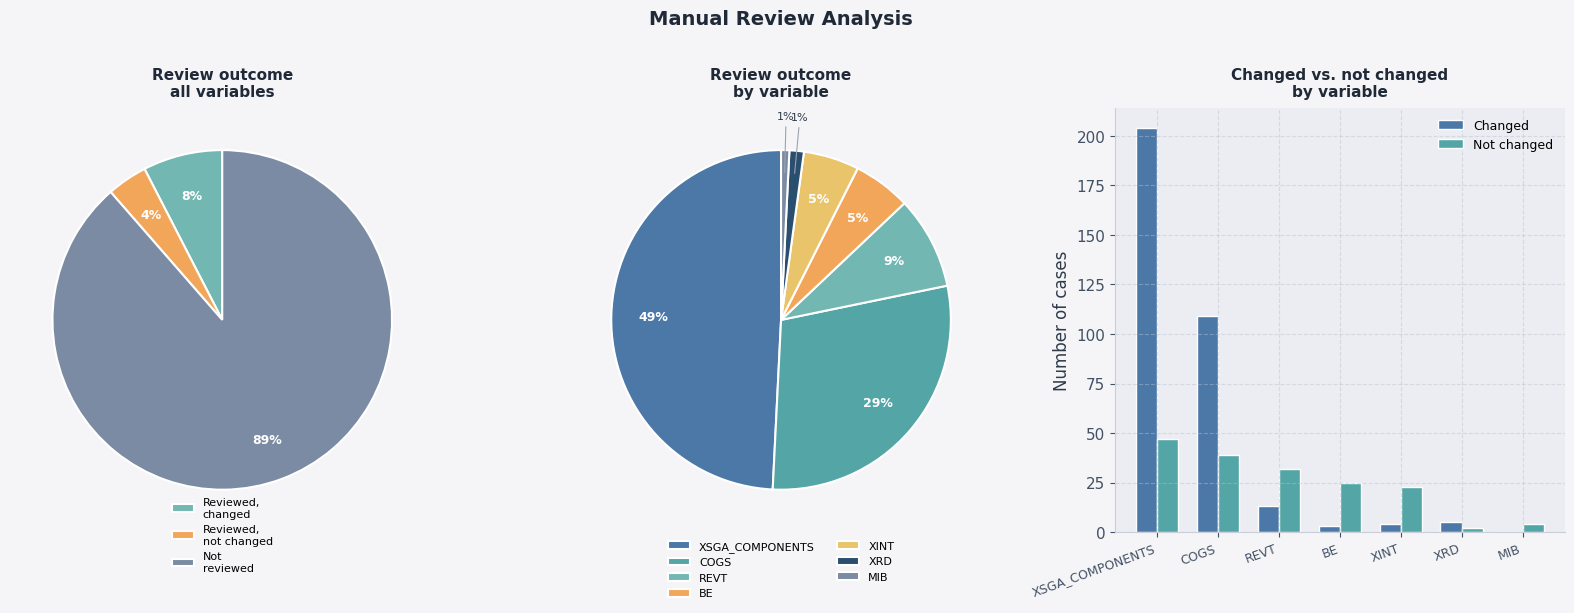

Total observations:                4466
Reviewed, changed (adj):            338
Reviewed, not changed:              172
Not reviewed:                      3956


In [96]:
import numpy as np
from matplotlib import gridspec

# ── Konstanter ─────────────────────────────────────────────────────────────
N_COMPANIES  = 638
N_VARIABLES  = 7
TOTAL_OBS    = N_COMPANIES * N_VARIABLES  # 4,466

MISSING_TAGS = ['CR:c|low|missing', 'CR:c|high|missing', 'CR:c||missing']
VARIABLES    = ['REVT', 'COGS', 'XSGA_COMPONENTS', 'XRD', 'XINT', 'BE', 'MIB']

# ── Rebuild per-variable counts from JSON ──────────────────────────────────
var_counts_c  = {v: 0.0 for v in VARIABLES}
var_counts_nc = {v: 0   for v in VARIABLES}

ROOT_PATH = Path("../data/mappings/prof_mappings")

for folder in ROOT_PATH.iterdir():
    if not folder.is_dir() or folder.name not in INCLUDE_FOLDERS:
        continue
    for jf in folder.rglob('*.json'):
        try:
            data = json.loads(jf.read_text(encoding='utf-8'))
        except Exception:
            continue
        for var_obj in data.get('variables', []):
            notes    = var_obj.get('notes', '') or ''
            variable = var_obj.get('variable', '')
            if variable not in VARIABLES:
                continue
            matched = find_tags(notes, TARGET_TAGS)
            if not matched:
                continue
            matched = apply_priority(matched)
            for tag in matched:
                is_missing = tag in MISSING_TAGS
                if tag.startswith('CR:c') or tag in ('R:c', 'OI:c'):
                    var_counts_c[variable] += 0.5 if is_missing else 1.0
                elif tag in ('CR:nc', 'R:nc', 'OI:nc'):
                    var_counts_nc[variable] += 1

var_counts_c = {v: round(val) for v, val in var_counts_c.items()}

# ── Totaler ────────────────────────────────────────────────────────────────
sum_c_adj    = sum(var_counts_c.values())
sum_nc       = sum(var_counts_nc.values())
not_reviewed = TOTAL_OBS - sum_c_adj - sum_nc

# ── Diagram data ───────────────────────────────────────────────────────────
pie1_values = [sum_c_adj, sum_nc, not_reviewed]
pie1_labels = ['Reviewed,\nchanged', 'Reviewed,\nnot changed', 'Not\nreviewed']
pie1_colors = [PALETTE['green'], PALETTE['orange'], PALETTE['slate']]

var_totals  = {v: var_counts_c[v] + var_counts_nc[v] for v in VARIABLES}
var_sorted  = sorted(var_totals, key=var_totals.get, reverse=True)
pie2_values = [var_totals[v] for v in var_sorted]
pie2_labels = var_sorted
pie2_colors = [PALETTE['blue'], PALETTE['teal'], PALETTE['green'],
               PALETTE['orange'], PALETTE['gold'], PALETTE['navy'],
               PALETTE['slate']][:len(var_sorted)]

r_c_per_var  = pd.Series({v: var_counts_c[v]  for v in var_sorted})
r_nc_per_var = pd.Series({v: var_counts_nc[v] for v in var_sorted})

# ── Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

threshold = 0.03

# ── Plot 1 ─────────────────────────────────────────────────────────────────
result1 = axes[0].pie(pie1_values, colors=pie1_colors, autopct=None, labels=None,
                      startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
wedges1 = result1[0]
total1  = sum(pie1_values)
for wedge, val in zip(wedges1, pie1_values):
    pct   = val / total1
    angle = (wedge.theta1 + wedge.theta2) / 2
    rad   = np.deg2rad(angle)
    if pct >= threshold:
        t = axes[0].text(0.75*np.cos(rad), 0.75*np.sin(rad), f'{pct*100:.0f}%',
                         ha='center', va='center', fontsize=9,
                         fontweight='semibold', zorder=10)
        t.set_color('white')
    else:
        axes[0].annotate(
            f'{pct*100:.0f}%',
            xy=(0.85*np.cos(rad), 0.85*np.sin(rad)),
            xytext=(1.2*np.cos(rad), 1.2*np.sin(rad)),
            ha='center', va='center', fontsize=8, color='#2f3b4a',
            arrowprops=dict(arrowstyle='-', color='#9ca3af', lw=0.8),
        )
axes[0].legend(labels=pie1_labels, loc='lower center', bbox_to_anchor=(0.5, -0.12),
               ncol=1, fontsize=8, frameon=False)
axes[0].set_title('Review outcome\nall variables', fontsize=11,
                  fontweight='bold', color='#1f2937', pad=8)

# ── Plot 2 ─────────────────────────────────────────────────────────────────
result2 = axes[1].pie(pie2_values, colors=pie2_colors, autopct=None, labels=None,
                      startangle=90,  
                      wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
wedges2 = result2[0]
total2  = sum(pie2_values)
for wedge, val in zip(wedges2, pie2_values):
    pct   = val / total2
    angle = (wedge.theta1 + wedge.theta2) / 2
    rad   = np.deg2rad(angle)
    if pct >= threshold:
        t = axes[1].text(0.75*np.cos(rad), 0.75*np.sin(rad), f'{pct*100:.0f}%',
                         ha='center', va='center', fontsize=9, fontweight='semibold', zorder=10)
        t.set_color('white')
    else:
        axes[1].annotate(
            f'{pct*100:.0f}%',
            xy=(0.85*np.cos(rad), 0.85*np.sin(rad)),
            xytext=(1.2*np.cos(rad), 1.2*np.sin(rad)),
            ha='center', va='center', fontsize=8, color='#2f3b4a',
            arrowprops=dict(arrowstyle='-', color='#9ca3af', lw=0.8),
        )
axes[1].legend(labels=pie2_labels, loc='lower center', bbox_to_anchor=(0.5, -0.18),
               ncol=2, fontsize=8, frameon=False)
axes[1].set_title('Review outcome\nby variable', fontsize=11,
                  fontweight='bold', color='#1f2937', pad=8)

# ── Plot 3 ─────────────────────────────────────────────────────────────────
x     = np.arange(len(var_sorted))
width = 0.35
axes[2].bar(x - width/2, r_c_per_var.values,  width, label='Changed',
            color=PALETTE['blue'], edgecolor='white')
axes[2].bar(x + width/2, r_nc_per_var.values, width, label='Not changed',
            color=PALETTE['teal'], edgecolor='white')
style_axis(axes[2], '', ylabel='Number of cases')
axes[2].set_title('Changed vs. not changed\nby variable', fontsize=11,
                  fontweight='bold', color='#1f2937', pad=8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(var_sorted, rotation=20, ha='right', fontsize=9)
axes[2].legend(fontsize=9)

fig.suptitle('Manual Review Analysis', fontsize=14, fontweight='bold', color='#1f2937', y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / '8_review_pie_analysis.png', dpi=150)
plt.show()

# ── Print summary ──────────────────────────────────────────────────────────
print(f"Total observations:              {TOTAL_OBS:>6}")
print(f"Reviewed, changed (adj):         {sum_c_adj:>6}")
print(f"Reviewed, not changed:           {sum_nc:>6}")
print(f"Not reviewed:                    {not_reviewed:>6}")

In [86]:
test_notes = "CR:c|high|missing. OI:c. An explicit populated SG&A-type row exists..."
matched = [tag for tag in TARGET_TAGS if tag in test_notes]
print("Matched:", matched)
print("has_cr_c:", any(t.startswith('CR:c') for t in matched))
print("After priority:", apply_priority(matched))

Matched: ['CR:c|high|missing', 'R:c', 'OI:c']
has_cr_c: True
After priority: ['CR:c|high|missing']


## Lagre flat CSV for videre analyse

In [ ]:
csv_path = OUT_DIR / 'mappings_review_flat.csv'
df.to_csv(csv_path, index=False)
print(f'CSV lagret: {csv_path}')
print(f'Kolonner: {list(df.columns)}')
df.head()